<a href="https://colab.research.google.com/github/Mithunmick/Predicting_Diabetes_Using_Machine_Learning/blob/main/mithun_project_tometoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Import Neccessary libraries
import numpy as np
import pandas as pd

# Import Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Import Model
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

#Import Sampler libraries
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as imbPipeline

# Set the decimal format
pd.options.display.float_format = "{:.2f}".format

In [ ]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

In [ ]:
df.head(10)
df.tail(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99990,Male,39.00,0,0,No Info,27.32,6.10,100,0
99991,Male,22.00,0,0,current,29.65,6.00,80,0
99992,Female,26.00,0,0,never,34.34,6.50,160,0
99993,Female,40.00,0,0,never,40.69,3.50,155,0
99994,Female,36.00,0,0,No Info,24.60,4.80,145,0
99995,Female,80.00,0,0,No Info,27.32,6.20,90,0
99996,Female,2.00,0,0,No Info,17.37,6.50,100,0
99997,Male,66.00,0,0,former,27.83,5.70,155,0
99998,Female,24.00,0,0,never,35.42,4.00,100,0
99999,Female,57.00,0,0,current,22.43,6.60,90,0


In [ ]:
# Handle duplicates
duplicate_rows_data = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (3854, 9)


In [ ]:
df = df.drop_duplicates()

In [ ]:
# Loop through each column and count the number of distinct values
for column in df.columns:
    num_distinct_values = len(df[column].unique())
    print(f"{column}: {num_distinct_values} distinct values")

gender: 3 distinct values
age: 102 distinct values
hypertension: 2 distinct values
heart_disease: 2 distinct values
smoking_history: 6 distinct values
bmi: 4247 distinct values
HbA1c_level: 18 distinct values
blood_glucose_level: 18 distinct values
diabetes: 2 distinct values


In [ ]:
# Checking null values
print(df.isnull().sum())

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


           age  hypertension  heart_disease      bmi  HbA1c_level  \
count 96146.00      96146.00       96146.00 96146.00     96146.00   
mean     41.79          0.08           0.04    27.32         5.53   
std      22.46          0.27           0.20     6.77         1.07   
min       0.08          0.00           0.00    10.01         3.50   
25%      24.00          0.00           0.00    23.40         4.80   
50%      43.00          0.00           0.00    27.32         5.80   
75%      59.00          0.00           0.00    29.86         6.20   
max      80.00          1.00           1.00    95.69         9.00   

       blood_glucose_level  diabetes  
count             96146.00  96146.00  
mean                138.22      0.09  
std                  40.91      0.28  
min                  80.00      0.00  
25%                 100.00      0.00  
50%                 140.00      0.00  
75%                 159.00      0.00  
max                 300.00      1.00  
gender                 0
ag

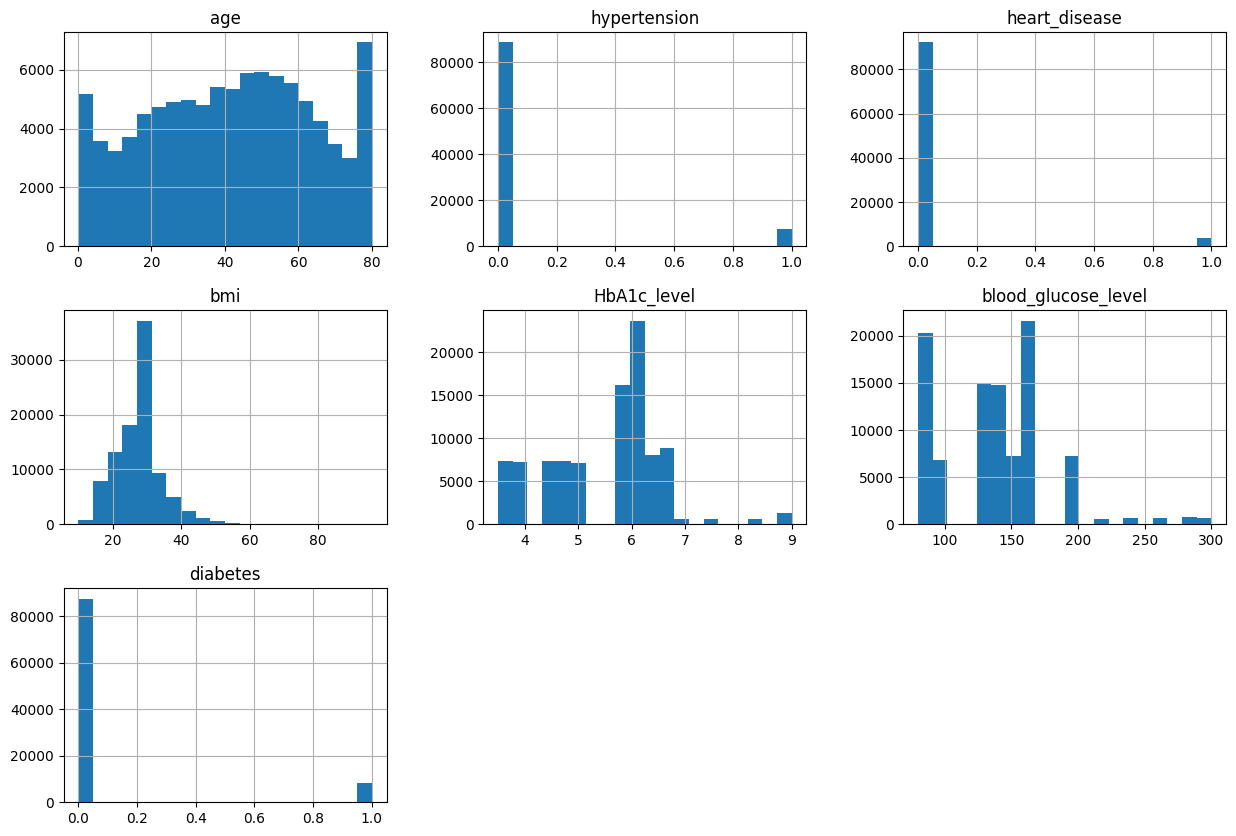

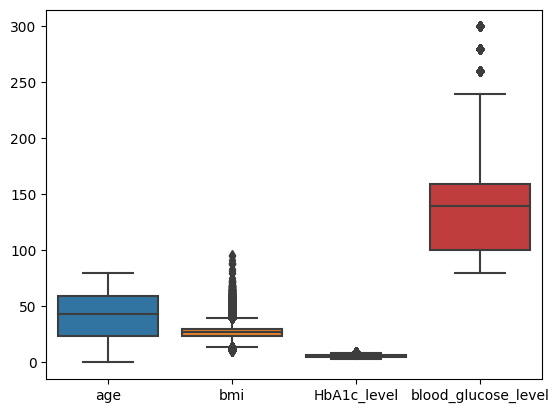

In [ ]:
# Summary statistics of numerical columns
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Distribution of numerical features
df.hist(bins=20, figsize=(15, 10))
plt.show()

# Boxplot to identify outliers
sns.boxplot(data=df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']])
plt.show()

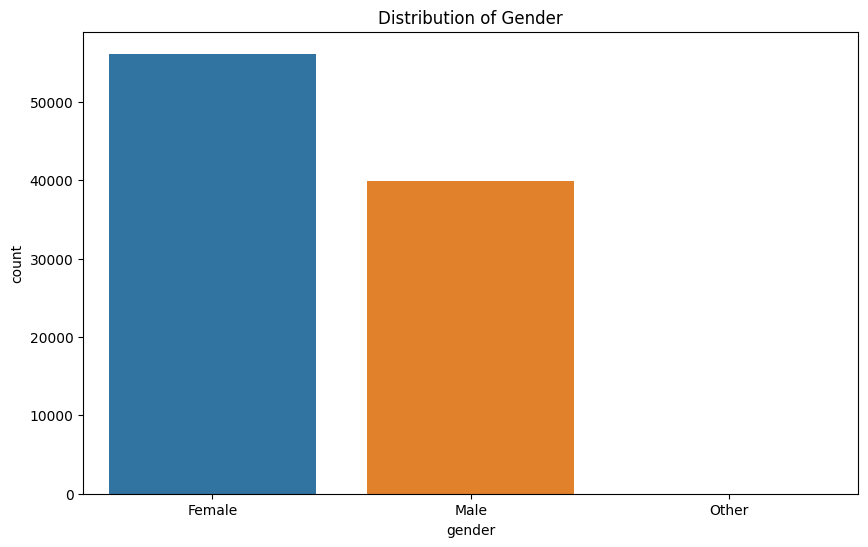

In [ ]:
# Count plot for categorical variables
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=df)
plt.title('Distribution of Gender')
plt.show()

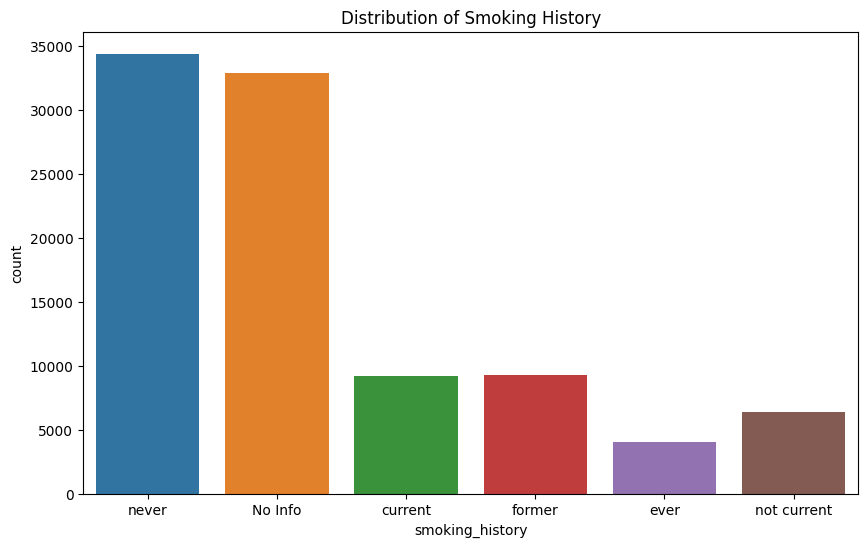

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='smoking_history', data=df)
plt.title('Distribution of Smoking History')
plt.show()

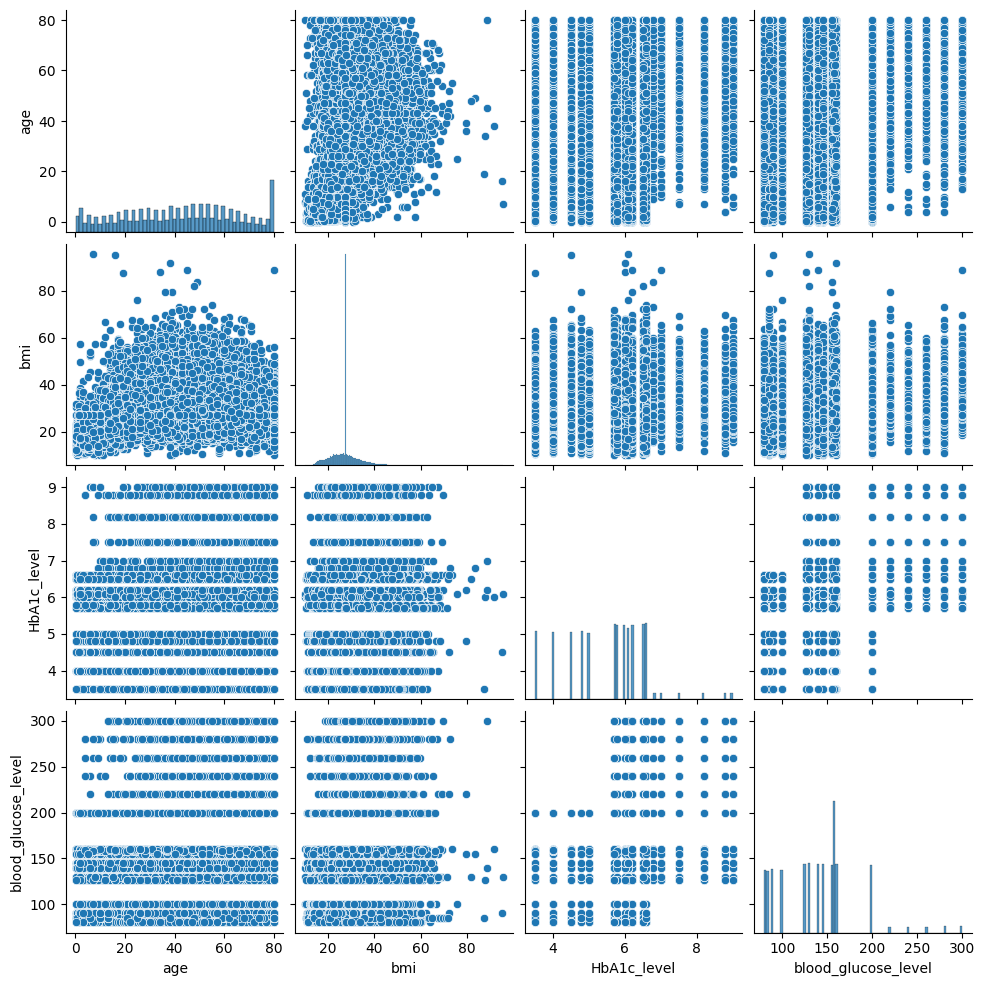

In [ ]:
# Scatter plot to explore relationships between numerical variables
sns.pairplot(df[['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']])
plt.show()

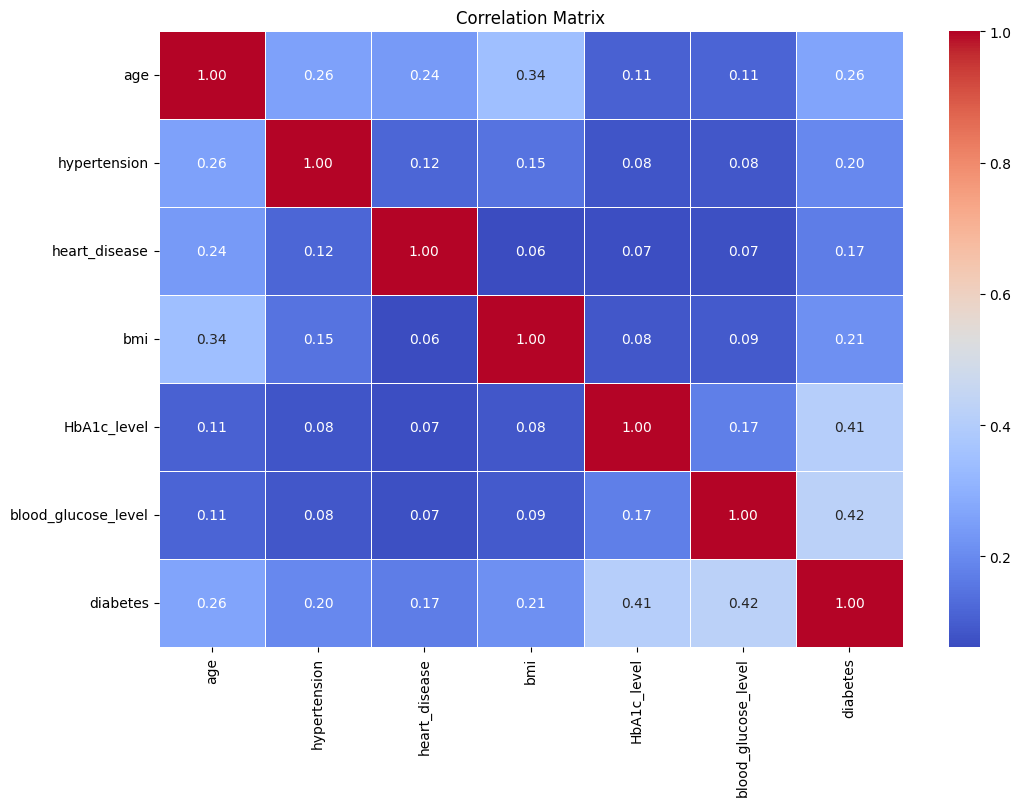

In [ ]:
# Correlation matrix and heatmap
correlation_matrix = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

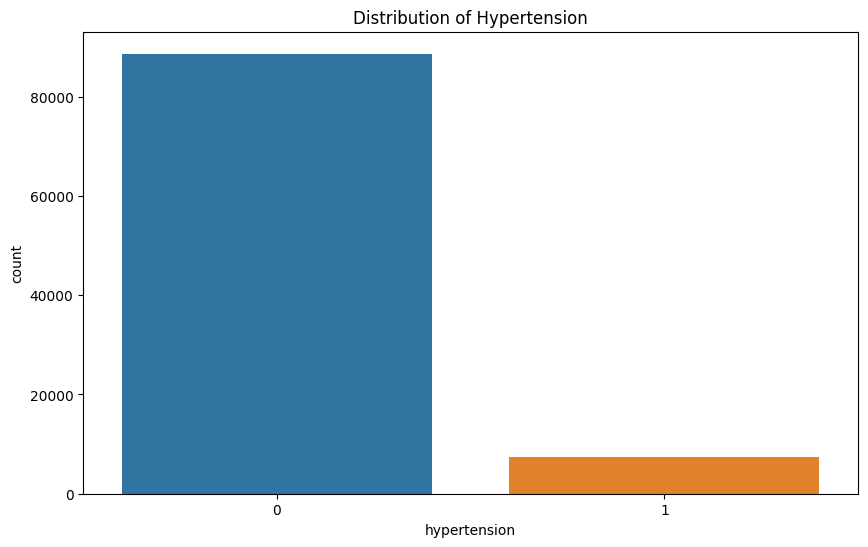

In [ ]:
# Bar plot for hypertension and heart disease
plt.figure(figsize=(10, 6))
sns.countplot(x='hypertension', data=df)
plt.title('Distribution of Hypertension')
plt.show()

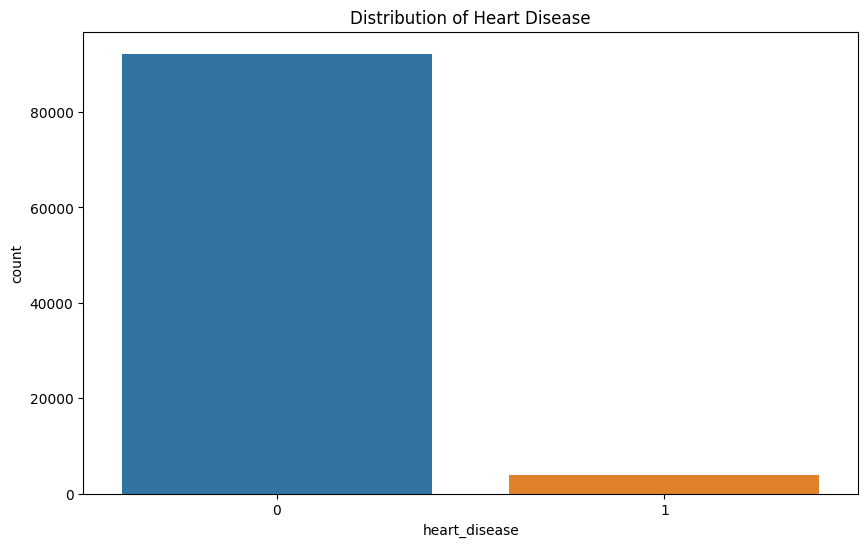

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='heart_disease', data=df)
plt.title('Distribution of Heart Disease')
plt.show()

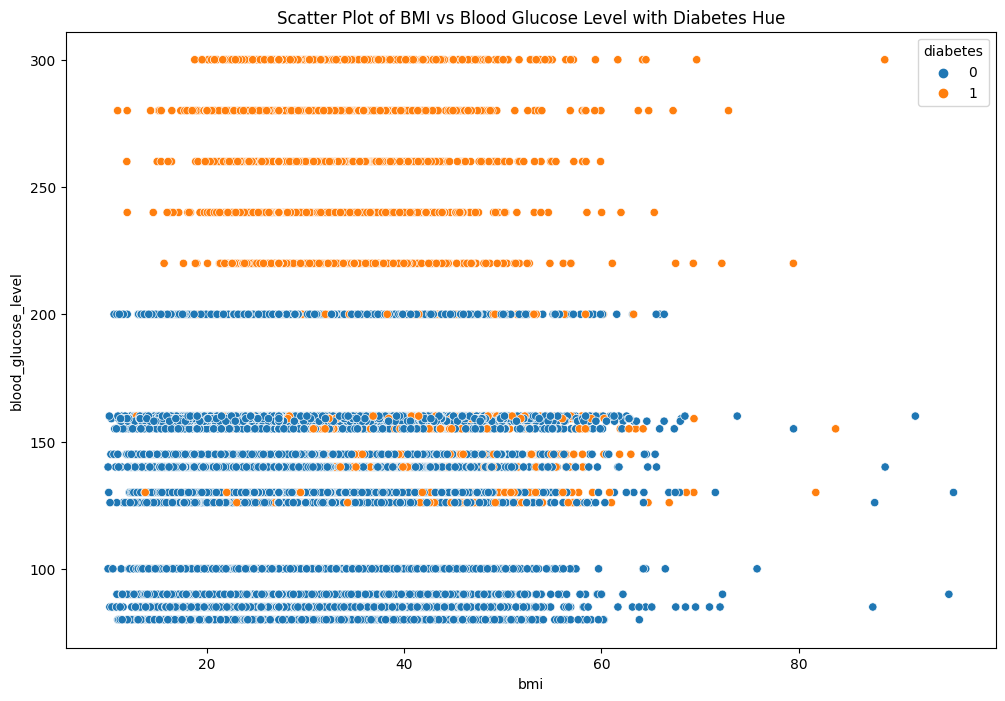

In [ ]:
# Scatter plot with hue for diabetes
plt.figure(figsize=(12, 8))
sns.scatterplot(x='bmi', y='blood_glucose_level', hue='diabetes', data=df)
plt.title('Scatter Plot of BMI vs Blood Glucose Level with Diabetes Hue')
plt.show()

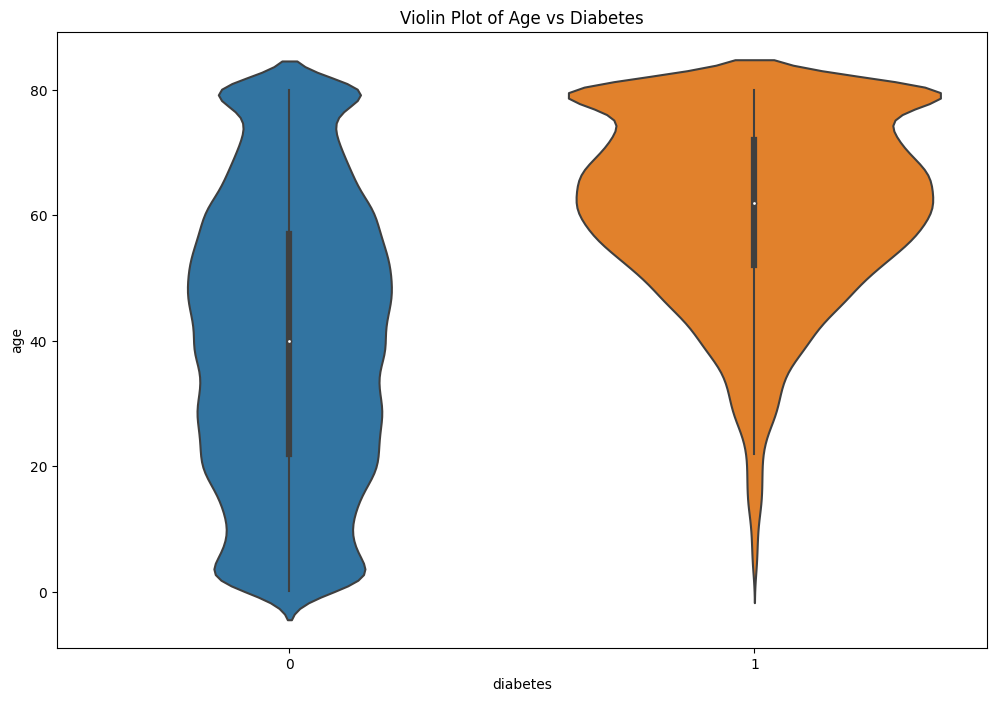

In [ ]:
# Violin plot for age and diabetes
plt.figure(figsize=(12, 8))
sns.violinplot(x='diabetes', y='age', data=df)
plt.title('Violin Plot of Age vs Diabetes')
plt.show()

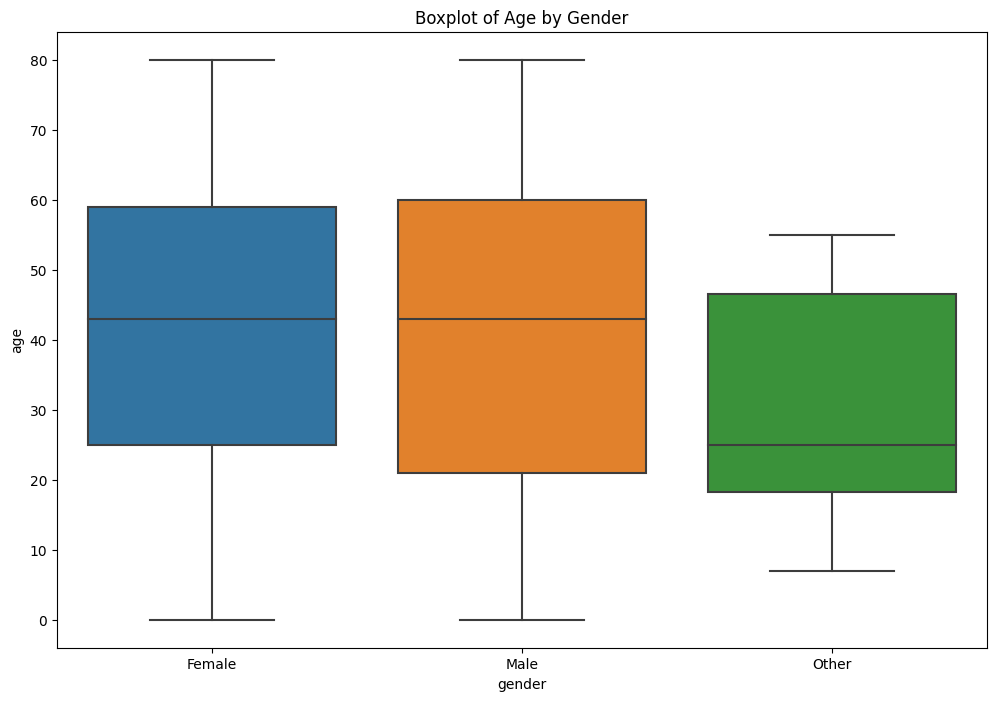

In [ ]:
# Boxplot for age and gender
plt.figure(figsize=(12, 8))
sns.boxplot(x='gender', y='age', data=df)
plt.title('Boxplot of Age by Gender')
plt.show()

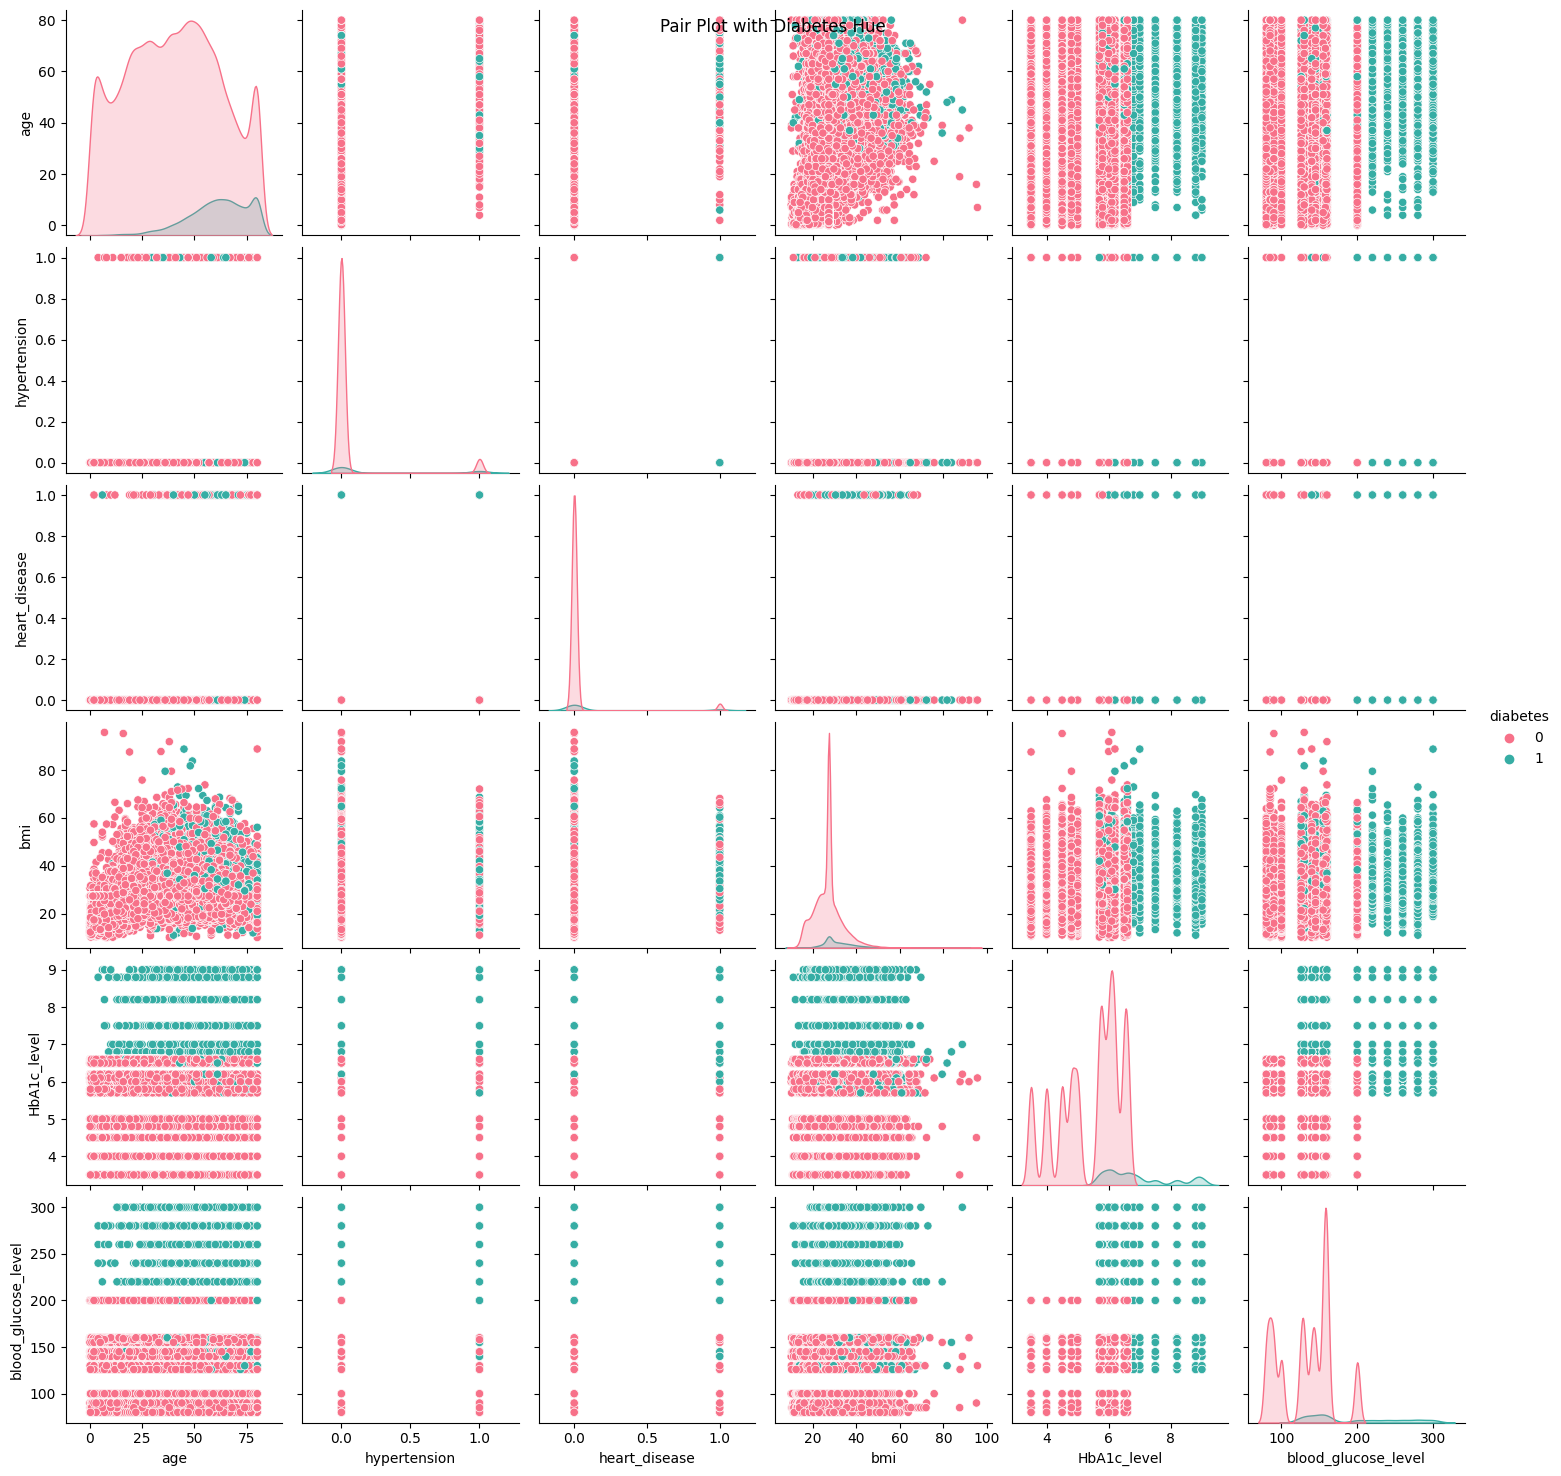

In [ ]:
# Pair plot with hue for diabetes
sns.pairplot(df, hue='diabetes', diag_kind='kde', palette='husl')
plt.suptitle('Pair Plot with Diabetes Hue')
plt.show()

In [ ]:
df.describe().style.format("{:.2f}")

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00,96146.00
mean,41.79,0.08,0.04,27.32,5.53,138.22,0.09
std,22.46,0.27,0.20,6.77,1.07,40.91,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.40,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,59.00,0.00,0.00,29.86,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


In [ ]:
# Define a function to map the existing categories to new ones
def recategorize_smoking(smoking_status):
    if smoking_status in ['never', 'No Info']:
        return 'non-smoker'
    elif smoking_status == 'current':
        return 'current'
    elif smoking_status in ['ever', 'former', 'not current']:
        return 'past_smoker'

# Apply the function to the 'smoking_history' column
df['smoking_history'] = df['smoking_history'].apply(recategorize_smoking)

# Check the new value counts
print(df['smoking_history'].value_counts())

non-smoker     67285
past_smoker    19664
current         9197
Name: smoking_history, dtype: int64


In [ ]:
data = df.copy()

In [ ]:
def perform_one_hot_encoding(df, column_name):
    # Perform one-hot encoding on the specified column
    dummies = pd.get_dummies(df[column_name], prefix=column_name)

    # Drop the original column and append the new dummy columns to the dataframe
    df = pd.concat([df.drop(column_name, axis=1), dummies], axis=1)

    return df

# Perform one-hot encoding on the gender variable
data = perform_one_hot_encoding(data, 'gender')

# Perform one-hot encoding on the smoking history variable
data = perform_one_hot_encoding(data, 'smoking_history')

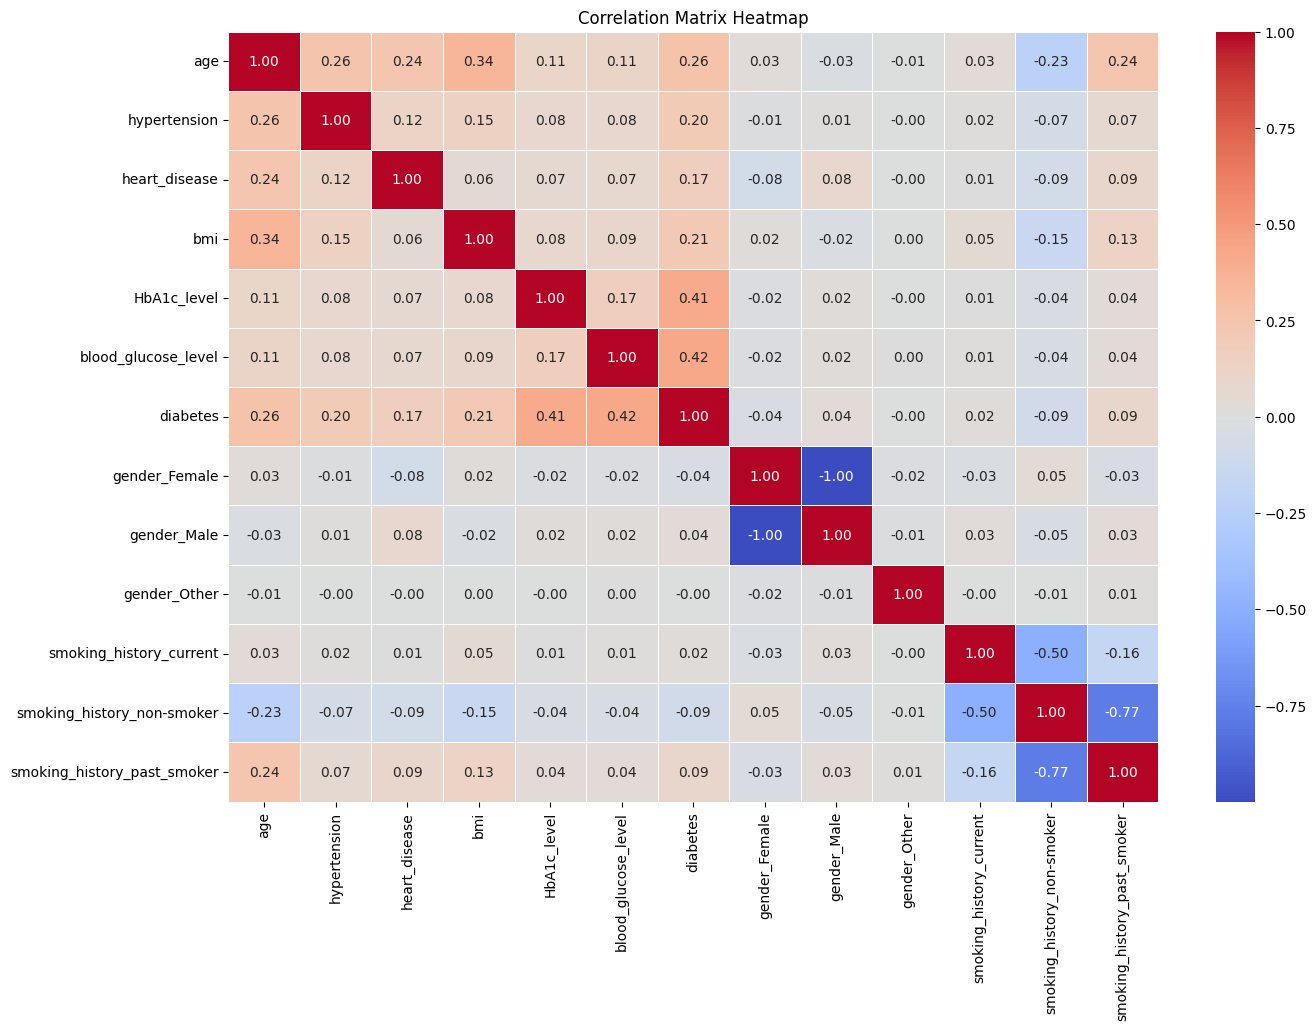

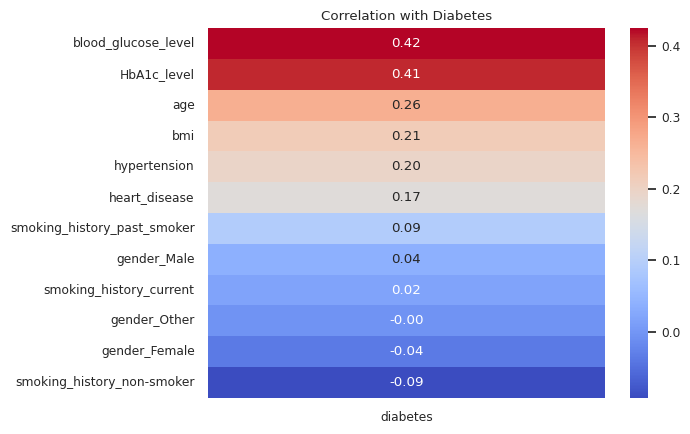

In [ ]:
# Compute the correlation matrix
correlation_matrix = data.corr()
#Graph I.
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()


#Graph II
# Create a heatmap of the correlations with the target column
corr = data.corr()
target_corr = corr['diabetes'].drop('diabetes')

# Sort correlation values in descending order
target_corr_sorted = target_corr.sort_values(ascending=False)

sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

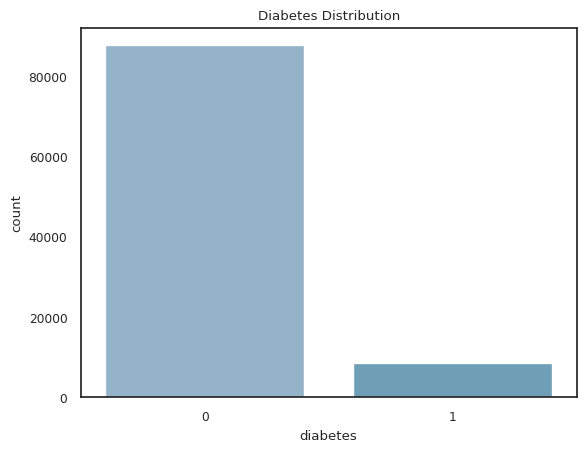

In [ ]:
# Count plot for the 'diabetes' variable
sns.countplot(x='diabetes', data=df)
plt.title('Diabetes Distribution')
plt.show()

In [ ]:
# Define resampling
over = SMOTE(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

In [ ]:
# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level','hypertension','heart_disease']),
        ('cat', OneHotEncoder(), ['gender','smoking_history'])
    ])

# Split data into features and target variable
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [ ]:
# Create a pipeline that preprocesses the data, resamples data, and then trains a classifier
clf = imbPipeline(steps=[('preprocessor', preprocessor),
                      ('over', over),
                      ('under', under),
                      ('classifier', RandomForestClassifier())])

In [ ]:
# Define the hyperparameters and the values we want to test
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

In [ ]:
# Create Grid Search object
grid_search = GridSearchCV(clf, param_grid, cv=5)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 50}
